# Experiment 05 — Client Update Geometry under Proximal Regularization

## 1. Research Question

Experiment 04 showed that moderate proximal regularization improved convergence under strong Dirichlet heterogeneity, while excessive regularization degraded learning.

This experiment investigates the mechanism behind that behavior by measuring the geometry of client updates before server aggregation.

For client (k) at communication round (t),

\[
\Delta_k^{(t)} = w_k^{(t)} - w_t,
\]

where (w_t) is the global model at the beginning of the round and (w_k^{(t)}) is the locally trained client model.

We study three diagnostics:

1. **Client update magnitude**
   \[
   \|\Delta_k^{(t)}\|_2
   \]
2. **Pairwise update alignment**
   \[
   \cos(\Delta_i^{(t)}, \Delta_j^{(t)})
   \]
3. **Aggregate update alignment**
   \[
   \cos(\Delta_k^{(t)}, \bar{\Delta}^{(t)})
   \]

The goal is to determine how proximal strength changes both the magnitude and direction of client updates under non-IID data.

## 2. Hypotheses

- **H1:** Increasing \(\mu\) will reduce client update magnitude because the FedProx objective penalizes deviation from the round-start global model.
- **H2:** Moderate proximal regularization may increase directional agreement between client updates under strong statistical heterogeneity.
- **H3:** Excessively large \(\mu\) may produce very small client updates, limiting useful local learning even if update disagreement is reduced.

## 3. Experimental Design

To isolate the effect of proximal regularization, all experimental conditions are held fixed except for \(\mu\).

Fixed conditions:

- Dataset: MNIST
- Clients: 5
- Partition: saved Dirichlet \(\alpha=0.1\) partition from Experiment 03
- Model: SimpleMLP
- Initialization: common saved \(w_0\)
- Local epochs: 5
- Communication rounds: 20
- Batch size: 64
- Learning rate: 0.01
- Client participation: \(C=1.0\)

The proximal settings are:

\[
\mu \in \{0,\ 0.1,\ 1.0\}.
\]

They represent the FedAvg-equivalent control, moderate regularization, and strong regularization, respectively.

## 4. Setup

In [106]:
from pathlib import Path
import os
import sys


def find_repo_root():
    """Find the repository root from VS Code, Kaggle, or Colab."""
    cwd = Path.cwd().resolve()

    candidates = [cwd, *cwd.parents]
    candidates += [
        Path("/kaggle/working/federated-learning-under-heterogeneity"),
        Path("/content/federated-learning-under-heterogeneity"),
    ]

    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()

    raise RuntimeError(
        "Repository root not found.\n"
        "Open the 'federated-learning-under-heterogeneity' folder in VS Code, "
        "or clone/cd into the repository before running this notebook."
    )


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root  :", REPO_ROOT)
print("Working dir:", Path.cwd())
print("Python     :", sys.executable)

Repo root  : D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity
Working dir: D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity
Python     : d:\Anaconda\python.exe


In [107]:
import copy
import json
import random
from dataclasses import asdict, dataclass
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from src.data import client_label_counts
from src.diagnostics import (
    cosine_similarity_updates,
    model_to_vector,
    model_update_vector,
    update_magnitude,
)
from src.fedprox import client_update_fedprox
from src.models import SimpleMLP
from src.training import aggregate, evaluate

print("Imports successful.")

Imports successful.


## 5. Configuration

In [108]:
@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42
    num_clients: int = 5

    alpha: float = 0.1
    mu_values: tuple = (0.0, 0.1, 1.0)

    local_epochs: int = 5
    num_rounds: int = 20
    batch_size: int = 64
    learning_rate: float = 0.01

    datasets_dir: str = "datasets"
    iid_results_dir: str = "results/iid_baseline"
    dirichlet_results_dir: str = "results/dirichlet_noniid"
    results_dir: str = "results/client_update_geometry"


CFG = ExperimentConfig()

RESULT_DIR = REPO_ROOT / CFG.results_dir
ALPHA_RESULT_DIR = RESULT_DIR / f"alpha_{str(CFG.alpha).replace('.', 'p')}"
FIGURE_DIR = ALPHA_RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
ALPHA_RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with (RESULT_DIR / "config.json").open("w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(CFG)
print("Device :", device)
print("Results:", RESULT_DIR)

ExperimentConfig(seed=42, num_clients=5, alpha=0.1, mu_values=(0.0, 0.1, 1.0), local_epochs=5, num_rounds=20, batch_size=64, learning_rate=0.01, datasets_dir='datasets', iid_results_dir='results/iid_baseline', dirichlet_results_dir='results/dirichlet_noniid', results_dir='results/client_update_geometry')
Device : cpu
Results: D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity\results\client_update_geometry


## 6. Utility Functions

In [109]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_mnist(root):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])

    train_ds = datasets.MNIST(
        root=root,
        train=True,
        download=True,
        transform=transform,
    )
    test_ds = datasets.MNIST(
        root=root,
        train=False,
        download=True,
        transform=transform,
    )

    return train_ds, test_ds


def load_torch_object(path, map_location="cpu"):
    """Load a saved PyTorch object across supported PyTorch versions."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def alpha_tag(alpha: float) -> str:
    return f"{alpha:g}".replace(".", "p")


def verify_partition(client_indices, dataset_size: int):
    flat_indices = [
        int(index)
        for indices in client_indices.values()
        for index in indices
    ]

    checks = {
        "dataset_size": dataset_size,
        "assigned": len(flat_indices),
        "unique": len(set(flat_indices)),
        "all_clients_nonempty": all(
            len(indices) > 0 for indices in client_indices.values()
        ),
    }

    if checks["assigned"] != dataset_size:
        raise ValueError("Partition lost or added examples.")
    if checks["unique"] != dataset_size:
        raise ValueError("Partition contains duplicate or missing indices.")
    if not checks["all_clients_nonempty"]:
        raise ValueError("At least one client is empty.")
    if min(flat_indices) < 0 or max(flat_indices) >= dataset_size:
        raise ValueError("Partition contains invalid dataset indices.")

    return checks

## 7. Load MNIST

In [110]:
set_seed(CFG.seed)

train_ds, test_ds = load_mnist(REPO_ROOT / CFG.datasets_dir)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
)

print("Training examples:", len(train_ds))
print("Test examples    :", len(test_ds))

Training examples: 60000
Test examples    : 10000


## 8. Reuse the Experiment 03 Partition

The severe heterogeneity condition is the saved Dirichlet \(\alpha=0.1\) partition from Experiment 03. The partition is loaded rather than regenerated so FedAvg and FedProx are compared on the same client datasets.

In [111]:
DIRICHLET_ALPHA_DIR = (
    REPO_ROOT
    / CFG.dirichlet_results_dir
    / f"alpha_{alpha_tag(CFG.alpha)}"
)
CLIENT_INDICES_PATH = DIRICHLET_ALPHA_DIR / "client_indices.pt"

if not CLIENT_INDICES_PATH.exists():
    raise FileNotFoundError(
        f"Missing Experiment 03 partition:\n{CLIENT_INDICES_PATH}"
    )

client_indices = load_torch_object(CLIENT_INDICES_PATH)
partition_checks = verify_partition(client_indices, len(train_ds))

print(partition_checks)
print("\nClient sizes:")
for client_id, indices in client_indices.items():
    print(f"Client {client_id}: {len(indices)} samples")

{'dataset_size': 60000, 'assigned': 60000, 'unique': 60000, 'all_clients_nonempty': True}

Client sizes:
Client 0: 8505 samples
Client 1: 8904 samples
Client 2: 13325 samples
Client 3: 21164 samples
Client 4: 8102 samples


In [112]:
source_distribution_path = (
    DIRICHLET_ALPHA_DIR / "client_label_distribution.csv"
)

if source_distribution_path.exists():
    label_distribution_df = pd.read_csv(source_distribution_path)
else:
    label_distribution_df = client_label_counts(train_ds, client_indices)

distribution_output_path = (
    ALPHA_RESULT_DIR / "client_label_distribution.csv"
)
label_distribution_df.to_csv(distribution_output_path, index=False)

digit_columns = [f"digit_{digit}" for digit in range(10)]
summary_columns = ["client", "samples", *digit_columns]
label_distribution_df[summary_columns]

,client,samples,digit_0,digit_1,digit_2,digit_3,digit_4,digit_5,digit_6,digit_7,digit_8,digit_9
0,0,8505,7,0,0,5526,16,0,15,756,2182,3
1,1,8904,0,91,627,11,2027,0,2306,0,3668,174
2,2,13325,79,0,5329,44,1625,0,3450,1,0,2797
3,3,21164,1721,6650,0,0,1950,5417,69,5357,0,0
4,4,8102,4116,1,2,550,224,4,78,151,1,2975


## 9. Controlled Initialization

Every condition starts from the same Experiment 01 checkpoint, \(w_0\). This prevents initialization differences from being confused with the effect of \(\mu\).

In [113]:
INITIAL_MODEL_PATH = (
    REPO_ROOT / CFG.iid_results_dir / "initial_model.pt"
)

if not INITIAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing initial checkpoint:\n{INITIAL_MODEL_PATH}"
    )

initial_state = load_torch_object(INITIAL_MODEL_PATH)

initial_model = SimpleMLP(784, 10)
initial_model.load_state_dict(initial_state)
initial_model.to(device)

loss_fn = nn.CrossEntropyLoss()
initial_loss, initial_accuracy = evaluate(
    initial_model,
    test_loader,
    loss_fn,
    device,
)

print(f"Initial loss    : {initial_loss:.6f}")
print(f"Initial accuracy: {initial_accuracy:.4f}")

assert abs(initial_loss - 2.313339) < 1e-3
assert abs(initial_accuracy - 0.1267) < 1e-4

Initial loss    : 2.313339
Initial accuracy: 0.1267


## 10. One-Round Diagnostic Function

For each round, every client starts from the same \(w_t\). The function stores each client update before calculating:

- update magnitude,
- pairwise alignment,
- alignment with the weighted aggregate update.

Only after all diagnostics are measured does the server aggregate the local models. The final assertion checks that the manually calculated aggregate update equals the server's actual model change.

In [114]:
def run_diagnostic_round(
    global_model,
    client_loaders,
    round_idx,
    local_epochs,
    learning_rate,
    loss_fn,
    device,
    mu,
):
    """Run one federated round and measure client-update geometry."""
    local_models = []
    client_sizes = []
    client_updates = {}

    global_vector = model_to_vector(global_model).clone()
    aggregate_update = torch.zeros_like(global_vector)
    total_client_size = 0

    magnitude_rows = []

    for client_id, client_loader in client_loaders.items():
        local_model = client_update_fedprox(
            global_model,
            client_loader,
            local_epochs,
            learning_rate,
            loss_fn,
            device,
            mu,
        )

        local_models.append(local_model)

        client_size = len(client_loader.dataset)
        client_sizes.append(client_size)
        total_client_size += client_size

        delta = model_update_vector(local_model, global_model)
        client_updates[client_id] = delta
        aggregate_update += client_size * delta

        magnitude_rows.append({
            "mu": mu,
            "round": round_idx,
            "local_epochs": local_epochs,
            "client_id": client_id,
            "update_magnitude": update_magnitude(delta).item(),
        })

    aggregate_update /= total_client_size

    aggregate_alignment_rows = []
    for client_id, delta in client_updates.items():
        aggregate_alignment_rows.append({
            "mu": mu,
            "round": round_idx,
            "local_epochs": local_epochs,
            "client_id": client_id,
            "aggregate_alignment": cosine_similarity_updates(
                delta,
                aggregate_update,
            ).item(),
        })

    pairwise_rows = []
    for client_i, client_j in combinations(client_updates.keys(), 2):
        pairwise_rows.append({
            "mu": mu,
            "round": round_idx,
            "local_epochs": local_epochs,
            "client_i": client_i,
            "client_j": client_j,
            "cosine_similarity": cosine_similarity_updates(
                client_updates[client_i],
                client_updates[client_j],
            ).item(),
        })

    new_global_model = aggregate(
        global_model,
        local_models,
        client_sizes,
    )

    # Verify that weighted update averaging matches server aggregation.
    server_update = model_to_vector(new_global_model) - global_vector
    assert torch.allclose(
        server_update,
        aggregate_update,
        rtol=1e-5,
        atol=1e-6,
    )

    return (
        new_global_model,
        magnitude_rows,
        pairwise_rows,
        aggregate_alignment_rows,
    )

## 11. Capped Local Validation Helpers

The capped loaders use only a small number of examples per client so the diagnostic pipeline can be checked quickly on a local machine. They are **only for validation** and must not be used for the final 20-round experiment.

In [115]:
def fresh_initial_model():
    model = SimpleMLP(784, 10)
    model.load_state_dict(copy.deepcopy(initial_state))
    model.to(device)
    return model


def make_capped_client_loaders(
    max_examples_per_client: int = 128,
    shuffle: bool = False,
):
    loaders = {}

    for client_id, indices in client_indices.items():
        capped_indices = list(indices)[:max_examples_per_client]
        loaders[client_id] = DataLoader(
            Subset(train_ds, capped_indices),
            batch_size=min(CFG.batch_size, len(capped_indices)),
            shuffle=shuffle,
        )

    return loaders


validation_loaders = make_capped_client_loaders()
print("Validation clients:", len(validation_loaders))
for client_id, loader in validation_loaders.items():
    print(f"Client {client_id}: {len(loader.dataset)} examples")

Validation clients: 5
Client 0: 128 examples
Client 1: 128 examples
Client 2: 128 examples
Client 3: 128 examples
Client 4: 128 examples


## 12. Capped Validation Experiment Runner

Each \(\mu\) condition resets the seed, reloads the same initial model, and recreates the capped client loaders. Within one condition, the returned global model becomes the starting model for the next communication round.

In [116]:
def run_diagnostic_experiment(
    mu_values,
    num_rounds,
    local_epochs,
    learning_rate,
    loss_fn,
    device,
    test_loader,
):
    """Run the diagnostic pipeline with capped client loaders."""
    all_magnitude_rows = []
    all_pairwise_rows = []
    all_aggregate_alignment_rows = []
    performance_rows = []

    for mu_value in mu_values:
        set_seed(CFG.seed)
        global_model = fresh_initial_model()
        client_loaders = make_capped_client_loaders()

        for round_idx in range(1, num_rounds + 1):
            (
                global_model,
                magnitude_rows,
                pairwise_rows,
                aggregate_alignment_rows,
            ) = run_diagnostic_round(
                global_model=global_model,
                client_loaders=client_loaders,
                round_idx=round_idx,
                local_epochs=local_epochs,
                learning_rate=learning_rate,
                loss_fn=loss_fn,
                device=device,
                mu=mu_value,
            )

            assert len(magnitude_rows) == CFG.num_clients
            assert len(pairwise_rows) == 10
            assert len(aggregate_alignment_rows) == CFG.num_clients

            test_loss, test_accuracy = evaluate(
                global_model,
                test_loader,
                loss_fn,
                device,
            )
            performance_rows.append({
                "mu": mu_value,
                "round": round_idx,
                "local_epochs": local_epochs,
                "test_loss": test_loss,
                "test_accuracy": test_accuracy,
            })

            all_magnitude_rows.extend(magnitude_rows)
            all_pairwise_rows.extend(pairwise_rows)
            all_aggregate_alignment_rows.extend(
                aggregate_alignment_rows
            )

    magnitude_df = pd.DataFrame(all_magnitude_rows)
    pairwise_df = pd.DataFrame(all_pairwise_rows)
    aggregate_alignment_df = pd.DataFrame(
        all_aggregate_alignment_rows
    )
    performance_df = pd.DataFrame(performance_rows)

    return (
        magnitude_df,
        pairwise_df,
        aggregate_alignment_df,
        performance_df,
    )

## 13. Plotting Helpers

In [117]:
def plot_update_magnitude(magnitude_df, round_idx, local_epochs):
    round_df = magnitude_df[magnitude_df["round"] == round_idx]

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=round_df,
        x="client_id",
        y="update_magnitude",
        hue="mu",
        errorbar=None,
    )

    plt.xlabel("Client")
    plt.ylabel(r"Update magnitude $\|\Delta_k\|_2$")
    plt.title(
        f"Client update magnitude — round {round_idx}, "
        f"E={local_epochs}"
    )
    plt.tight_layout()
    plt.show()


def plot_pairwise_alignment(pairwise_df, round_idx, local_epochs):
    round_df = pairwise_df[pairwise_df["round"] == round_idx]

    if round_df.empty:
        raise ValueError(f"No pairwise results for round {round_idx}.")

    mu_values = sorted(round_df["mu"].unique())
    clients = sorted(
        set(round_df["client_i"]) | set(round_df["client_j"])
    )

    fig, axes = plt.subplots(
        1,
        len(mu_values),
        figsize=(5 * len(mu_values), 4),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, mu in zip(axes, mu_values):
        mu_df = round_df[round_df["mu"] == mu]

        matrix = pd.DataFrame(
            np.eye(len(clients)),
            index=clients,
            columns=clients,
        )

        for row in mu_df.itertuples(index=False):
            matrix.loc[row.client_i, row.client_j] = (
                row.cosine_similarity
            )
            matrix.loc[row.client_j, row.client_i] = (
                row.cosine_similarity
            )

        sns.heatmap(
            matrix,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            center=0,
            square=True,
            cbar=ax is axes[-1],
            cbar_kws={"label": "Cosine similarity"},
        )

        ax.set_title(rf"$\mu={mu}$")
        ax.set_xlabel("Client")
        ax.set_ylabel("Client")

    fig.suptitle(
        f"Pairwise client-update alignment — round {round_idx}, "
        f"E={local_epochs}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

## 14. One-Round Capped Validation

This run checks the complete diagnostic pipeline with \(E=5\) and all three \(\mu\) values. It is not a final experimental result because each client is capped at 128 examples.

In [118]:
(
    magnitude_df,
    pairwise_df,
    aggregate_alignment_df,
    performance_df,
) = run_diagnostic_experiment(
    mu_values=CFG.mu_values,
    num_rounds=1,
    local_epochs=CFG.local_epochs,
    learning_rate=CFG.learning_rate,
    loss_fn=loss_fn,
    device=device,
    test_loader=test_loader,
)

In [119]:
assert len(magnitude_df) == 15
assert len(pairwise_df) == 30
assert len(aggregate_alignment_df) == 15
assert len(performance_df) == 3

assert magnitude_df["local_epochs"].eq(CFG.local_epochs).all()
assert pairwise_df["local_epochs"].eq(CFG.local_epochs).all()
assert aggregate_alignment_df["local_epochs"].eq(
    CFG.local_epochs
).all()

assert magnitude_df["update_magnitude"].notna().all()
assert pairwise_df["cosine_similarity"].between(-1, 1).all()
assert aggregate_alignment_df["aggregate_alignment"].between(
    -1,
    1,
).all()

print("One-round capped validation passed.")

One-round capped validation passed.


### 14.1 Update Magnitude

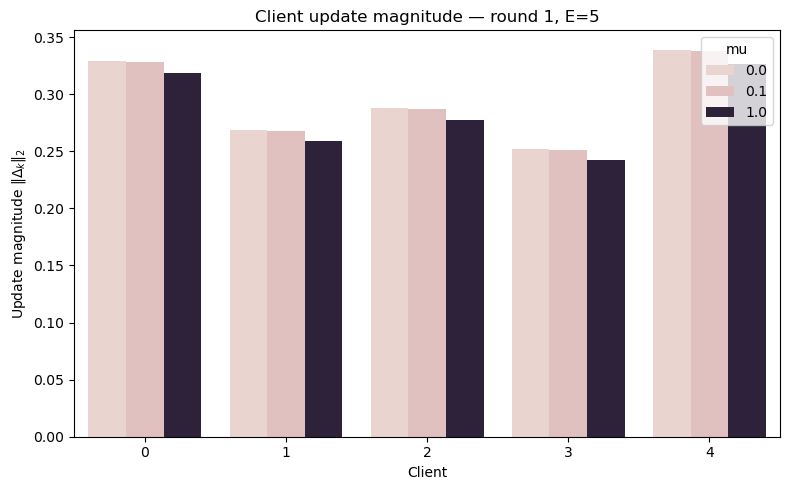

In [120]:
plot_update_magnitude(
    magnitude_df,
    round_idx=1,
    local_epochs=CFG.local_epochs,
)

In [121]:
magnitude_summary = (
    magnitude_df
    .groupby("mu")["update_magnitude"]
    .agg(["mean", "min", "max"])
)

fedavg_mean = magnitude_summary.loc[0.0, "mean"]

for mu in (0.1, 1.0):
    mu_mean = magnitude_summary.loc[mu, "mean"]
    reduction = (fedavg_mean - mu_mean) / fedavg_mean * 100
    print(f"mu={mu}: mean-magnitude reduction = {reduction:.4f}%")

magnitude_summary

mu=0.1: mean-magnitude reduction = 0.3764%
mu=1.0: mean-magnitude reduction = 3.6126%


,mean,min,max
mu,,,
0.0,0.295389,0.251806,0.338922
0.1,0.294277,0.250836,0.337654
1.0,0.284717,0.242197,0.326742


### 14.2 Pairwise Update Alignment

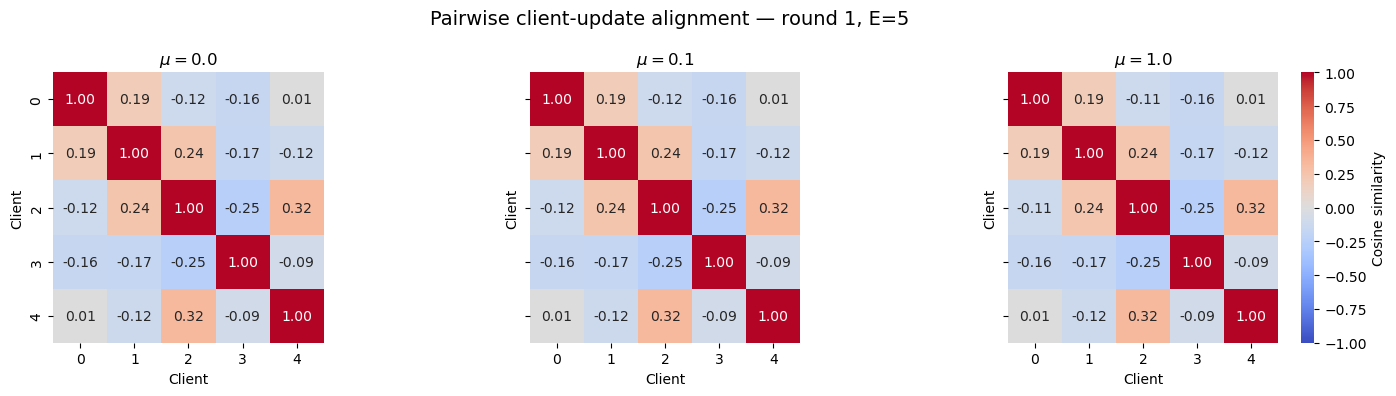

In [122]:
plot_pairwise_alignment(
    pairwise_df,
    round_idx=1,
    local_epochs=CFG.local_epochs,
)

In [123]:
pair_comparison = pairwise_df.pivot(
    index=["client_i", "client_j"],
    columns="mu",
    values="cosine_similarity",
)

pair_comparison["change_mu01"] = (
    pair_comparison[0.1] - pair_comparison[0.0]
)
pair_comparison["change_mu1"] = (
    pair_comparison[1.0] - pair_comparison[0.0]
)

pair_comparison

mu                      0.0       0.1       1.0  change_mu01  change_mu1
client_i client_j                                                       
0        1         0.190511  0.190095  0.189779    -0.000417   -0.000732
         2        -0.116181 -0.115962 -0.113986     0.000220    0.002195
         3        -0.157699 -0.157744 -0.157056    -0.000044    0.000643
         4         0.006259  0.006115  0.006516    -0.000145    0.000256
1        2         0.243706  0.243668  0.239094    -0.000038   -0.004611
         3        -0.167567 -0.167577 -0.168155    -0.000010   -0.000588
         4        -0.123484 -0.123561 -0.124252    -0.000077   -0.000768
2        3        -0.252068 -0.251602 -0.252653     0.000466   -0.000585
         4         0.323392  0.323105  0.323026    -0.000287   -0.000365
3        4        -0.092381 -0.092474 -0.093050    -0.000093   -0.000669

### 14.3 Aggregate Update Alignment

In [124]:
aggregate_alignment_df.pivot(
    index="client_id",
    columns="mu",
    values="aggregate_alignment",
)

mu,0.0,0.1,1.0
client_id,,,
0,0.470594,0.470655,0.473571
1,0.483448,0.483236,0.481040
2,0.549765,0.549806,0.548186
3,0.077424,0.077540,0.076099
4,0.574391,0.574162,0.574041


### 14.4 Global Test Performance

In [125]:
performance_df

,mu,round,local_epochs,test_loss,test_accuracy
0,0.0,1,5,2.240780,0.2223
1,0.1,1,5,2.240987,0.2220
2,1.0,1,5,2.242861,0.2206


## 15. Next Validation Step

Before the full Kaggle experiment:

1. Run this capped validation for two communication rounds.
2. Confirm the expected row counts and that all assertions pass.
3. Replace the capped client loaders with loaders built from the complete saved \(\alpha=0.1\) partition.
4. Preserve the same initialization, partition, batch size, learning rate, local epochs, and seeded minibatch ordering for every \(\mu\).

The full 20-round experiment should not use `make_capped_client_loaders()`.